# Text Preprocessing for NLP — NLTK, RegEx, spaCy & Contractions

For this assignment I went through four of the most commonly used text-preprocessing tools in NLP — **NLTK**, **RegEx**, **spaCy**, and the **`contractions`** library — tried each one individually, and then combined them into a full preprocessing pipeline on a real dataset.

I picked a set of tweets from NLTK's built-in Twitter corpus (`twitter_samples`) as my dataset. It's basically a smaller, ready-to-use version of the kind of data behind Kaggle's [Sentiment140 dataset](https://www.kaggle.com/datasets/kazanova/sentiment140) — real tweets, so genuinely messy: mentions, hashtags, links, slang, emoticons, contractions, random capitalization. Pretty much a perfect stress test for a preprocessing pipeline, and it saves me from needing a Kaggle API key just to download something.

**What's below:**
1. A quick individual demo of each tool
2. Loading and looking at the dataset
3. Building the pipeline step by step — cleaning → contractions → punctuation → tokenization → stopwords → lemmatization/stemming
4. Combining everything into one function and running it on the whole dataset
5. A quick sanity check to confirm the cleaning actually did something

## 0. Setup

Installing the four libraries, plus the extra data each one needs — NLTK's `punkt`, `stopwords` and `wordnet` resources, and spaCy's small English model (`en_core_web_sm`).

In [1]:
!pip install nltk spacy contractions pandas matplotlib -q
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import nltk

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)

print("NLTK data ready")

NLTK data ready


In [3]:
import re
import random
import contractions
import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, twitter_samples
from nltk.stem import PorterStemmer, WordNetLemmatizer

nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

random.seed(42)  # so the "random" sample below is the same every time this runs

print("All set.")

All set.


## 1. Getting a feel for each tool

Before touching the actual dataset, I wanted to see what each library does on its own, on a small example.

### 1.1 NLTK

The classic Python NLP library — tokenizing, stopword lists, stemmers and lemmatizers all live here.

In [4]:
sentence = "The quick brown foxes are jumping over the lazy dogs near the river!"

tokens = word_tokenize(sentence)
print("Tokens:", tokens)

print(f"\nNLTK's English stopword list has {len(stop_words)} words in it, e.g.:")
print(list(stop_words)[:10])

Tokens: ['The', 'quick', 'brown', 'foxes', 'are', 'jumping', 'over', 'the', 'lazy', 'dogs', 'near', 'the', 'river', '!']

NLTK's English stopword list has 198 words in it, e.g.:
["it'd", 'wouldn', 'but', 'doesn', 'some', 'our', 'more', 'the', 'wasn', 'after']


### 1.2 RegEx

Not an NLP-specific tool, but honestly the workhorse for cleaning messy text — stripping URLs, mentions, HTML, punctuation, or any other pattern you can describe.

In [5]:
messy = "Check this out!!! \U0001F60D https://example.com/offer  @john_doe said it costs $29.99 <br> #discount"
print("Original:      ", messy)

step = re.sub(r"http\S+", "", messy)
print("No URL:        ", step)

step = re.sub(r"@\w+", "", step)
print("No mention:    ", step)

step = re.sub(r"<.*?>", "", step)
print("No HTML tag:   ", step)

step = re.sub(r"[^\w\s]", "", step)
print("No punctuation:", step)

step = re.sub(r"\s+", " ", step).strip()
print("Final:         ", step)

Original:       Check this out!!! 😍 https://example.com/offer  @john_doe said it costs $29.99 <br> #discount
No URL:         Check this out!!! 😍   @john_doe said it costs $29.99 <br> #discount
No mention:     Check this out!!! 😍    said it costs $29.99 <br> #discount
No HTML tag:    Check this out!!! 😍    said it costs $29.99  #discount
No punctuation: Check this out     said it costs 2999  discount
Final:          Check this out said it costs 2999 discount


### 1.3 spaCy

A step up from NLTK in terms of "understanding" text — it works out part-of-speech tags, lemmas and named entities automatically as it processes a sentence, without needing to be told what kind of word something is first (more on why that matters in the lemmatization section below).

In [6]:
doc = nlp("Apple was founded by Steve Jobs and is now looking at buying a startup in the UK for $1 billion.")

pd.DataFrame([(t.text, t.pos_, t.lemma_) for t in doc], columns=["token", "POS", "lemma"])

,token,POS,lemma
0,Apple,PROPN,Apple
1,was,AUX,be
2,founded,VERB,found
3,by,ADP,by
4,Steve,PROPN,Steve
5,Jobs,PROPN,Jobs
6,and,CCONJ,and
7,is,AUX,be
8,now,ADV,now
9,looking,VERB,look


It also picks up named entities on its own:

In [7]:
for ent in doc.ents:
    print(f"{ent.text:<15} {ent.label_}")

Apple           ORG
Steve Jobs      PERSON
UK              GPE
$1 billion      MONEY


### 1.4 contractions

Small library, one job: expand contractions and informal short forms into full words. I run this *before* stripping punctuation, since it needs the apostrophe to recognize a word like "haven't".

In [8]:
sample = "I don't think it's gonna work, y'all haven't even tried it yet."
print("Before:", sample)
print("After :", contractions.fix(sample))

Before: I don't think it's gonna work, y'all haven't even tried it yet.
After : I do not think it is going to work, you all have not even tried it yet.


## 2. The dataset

I'm using NLTK's `twitter_samples` corpus — 5,000 positive and 5,000 negative tweets, hand-labeled for sentiment. For this notebook I only need a manageable slice, so I'm taking a random 150 of each (300 tweets total) to keep it quick to run.

In [9]:
positive_tweets = twitter_samples.strings("positive_tweets.json")
negative_tweets = twitter_samples.strings("negative_tweets.json")
print(f"{len(positive_tweets)} positive tweets, {len(negative_tweets)} negative tweets available")

sample_pos = random.sample(positive_tweets, 150)
sample_neg = random.sample(negative_tweets, 150)

df = pd.DataFrame(
    [{"text": t, "sentiment": "positive"} for t in sample_pos]
    + [{"text": t, "sentiment": "negative"} for t in sample_neg]
).sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

5000 positive tweets, 5000 negative tweets available
(300, 2)


,text,sentiment
0,"but srsly tho, bae looks so out of it :((((",negative
1,@Suzy_slutcake I do have plans.. But looking l...,negative
2,And AS SOON as I tweeted that she planted her ...,negative
3,@ciaela get well soon :) xx,positive
4,Of course I always miss @selenagomez's Tweetin...,negative


## 3. Building the pipeline, step by step

Instead of jumping straight to one big function, I want to walk one tweet through every step so I can actually see what's happening. Here's the one I'm using — it's got a mention, a hashtag, a URL, a contraction, an emoticon and some random capitalization, so it touches basically everything the pipeline needs to handle:

In [10]:
hero_tweet = "Hey Fam! Vote for @5SOS if you haven't already :) WE GOTTA WIN THIS FOR OUR BOYS! #TeenChoice -S http://t.co/zBZvXC0v5y"
print(hero_tweet)

Hey Fam! Vote for @5SOS if you haven't already :) WE GOTTA WIN THIS FOR OUR BOYS! #TeenChoice -S http://t.co/zBZvXC0v5y


### 3.1 Cleaning the text

First pass: lowercase everything, and strip the Twitter-specific noise — URLs, `@mentions`, a leading "RT" if it's a retweet, the `#` symbol (keeping the actual word, since "TeenChoice" still carries meaning), and any leftover HTML entities like `&amp;`.

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"^rt\s+", "", text)             # leading retweet marker
    text = re.sub(r"http\S+|www\.\S+", "", text)   # URLs
    text = re.sub(r"@\w+", "", text)                # @mentions
    text = re.sub(r"#", "", text)                   # hashtag symbol (keep the word)
    text = re.sub(r"&\w+;", "", text)                # HTML entities
    return text

step1 = clean_text(hero_tweet)
print(step1)

hey fam! vote for  if you haven't already :) we gotta win this for our boys! teenchoice -s 


### 3.2 Expanding contractions

Doing this *before* removing punctuation on purpose — `contractions.fix()` needs the apostrophe to recognize "haven't" as "have not". Strip the punctuation first and it just sees "havent" and leaves it alone.

In [12]:
step2 = contractions.fix(step1)
print(step2)

hey fam! vote for  if you have not already :) we got to win this for our boys! teenchoice -s 


### 3.3 Removing unwanted characters & punctuation

Now that contractions are expanded, it's safe to strip everything that isn't a plain lowercase letter — punctuation, digits, emoji/non-ASCII characters — and collapse any leftover extra spaces.

In [13]:
def strip_unwanted(text):
    text = re.sub(r"[^\x00-\x7F]+", " ", text)   # emoji / non-ASCII
    text = re.sub(r"[^a-z\s]", " ", text)         # punctuation + digits
    text = re.sub(r"\s+", " ", text).strip()
    return text

step3 = strip_unwanted(step2)
print(step3)

hey fam vote for if you have not already we got to win this for our boys teenchoice s


### 3.4 Tokenization

Splitting the cleaned string into individual word tokens.

In [14]:
tokens = word_tokenize(step3)
print(tokens)

['hey', 'fam', 'vote', 'for', 'if', 'you', 'have', 'not', 'already', 'we', 'got', 'to', 'win', 'this', 'for', 'our', 'boys', 'teenchoice', 's']


### 3.5 Stop-word removal

Dropping words like "the", "for", "if" that carry basically no meaning on their own. I'm also dropping anything 2 characters or shorter here, mostly to catch leftover fragments like the stray "s" below (a side effect of "gotta" expanding to "got to").

In [15]:
tokens_clean = [t for t in tokens if t not in stop_words and len(t) > 2]
print(tokens_clean)

['hey', 'fam', 'vote', 'already', 'got', 'win', 'boys', 'teenchoice']


### 3.6 Lemmatization vs. stemming

Both reduce a word to some "root" form, but differently: **stemming** chops off common suffixes using fixed rules — fast, but the result isn't always a real word. **Lemmatization** looks the word up and returns an actual dictionary form. Here's the difference on a handful of classic tricky words:

In [16]:
words = ["running", "better", "studies", "was", "mice", "flies", "happier"]
pos_hint = {"running": "v", "better": "a", "studies": "n", "was": "v", "mice": "n", "flies": "v", "happier": "a"}

comparison = pd.DataFrame({
    "word": words,
    "stem": [stemmer.stem(w) for w in words],
    "lemma (default)": [lemmatizer.lemmatize(w) for w in words],
    "lemma (POS-aware)": [lemmatizer.lemmatize(w, pos=pos_hint[w]) for w in words],
})
comparison

,word,stem,lemma (default),lemma (POS-aware)
0,running,run,running,run
1,better,better,better,good
2,studies,studi,study,study
3,was,wa,wa,be
4,mice,mice,mouse,mouse
5,flies,fli,fly,fly
6,happier,happier,happier,happy


Some of that is pretty rough — the stemmer turns "studies" into "studi" and "flies" into "fli" (not real words), and by default the lemmatizer misses "better" and "happier" completely, since it assumes every word is a noun unless told otherwise. Give it the correct part of speech, though, and it gets everything right: "better" → "good", "happier" → "happy", "was" → "be". This is exactly the gap spaCy's lemmatizer fills automatically — back in section 1.3 it got "was" → "be" right with zero hints, because it works out the part of speech for you as it goes.

For the tweet I'm tracking, here's stemming vs. plain lemmatization on the tokens from 3.5:

In [17]:
stemmed = [stemmer.stem(t) for t in tokens_clean]
lemmatized = [lemmatizer.lemmatize(t) for t in tokens_clean]
print("Stemmed:    ", stemmed)
print("Lemmatized: ", lemmatized)

Stemmed:     ['hey', 'fam', 'vote', 'alreadi', 'got', 'win', 'boy', 'teenchoic']
Lemmatized:  ['hey', 'fam', 'vote', 'already', 'got', 'win', 'boy', 'teenchoice']


I'm going with lemmatization for the actual pipeline — real words are just easier to read afterward. I'm keeping it in the simple default (noun) mode rather than adding full POS-tagging, mainly to keep the function short; it won't be perfect (as 3.6 shows above), but it's good enough for cleaning text before something like a bag-of-words or TF-IDF step.

## 4. Putting it all together

Folding every step above into one function and running it over the whole dataset.

In [18]:
def preprocess(text):
    # cleaning
    text = text.lower()
    text = re.sub(r"^rt\s+", "", text)
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"&\w+;", "", text)
    # contractions (before punctuation gets stripped)
    text = contractions.fix(text)
    # punctuation / digits / non-ascii
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    # tokenize, drop stopwords + short tokens, lemmatize
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess)
df[["text", "clean_text"]].head(10)

,text,clean_text
0,"but srsly tho, bae looks so out of it :((((",srsly though bae look
1,@Suzy_slutcake I do have plans.. But looking l...,plan looking like girl issue may stop play
2,And AS SOON as I tweeted that she planted her ...,soon tweeted planted claw thigh traction zoome...
3,@ciaela get well soon :) xx,get well soon
4,Of course I always miss @selenagomez's Tweetin...,course always miss tweeting spree
5,I have puffy eyelids :(,puffy eyelid
6,"@jenandmish @wittykrushnic to get by, to get b...",get get
7,"""@yettygeers: When God gives us strength, His ...",god give strength purpose help others struggling
8,Ain't it too early forrit!!..wah happened to t...,early forrit wah happened tea bread bacon butt...
9,♛♛♛\n》》》》 \nI LOVE YOU SO MUCH.\nI BELİEVE THA...,love much beli eve follow please follow please...


## 5. Quick sanity check — did it actually help?

Before calling this done, I wanted to actually confirm the cleaning made a difference rather than just assuming it did.

In [19]:
before_vocab = set(w for t in df["text"] for w in word_tokenize(t.lower()))
after_vocab = set(w for t in df["clean_text"] for w in t.split())

print("Unique tokens before cleaning:", len(before_vocab))
print("Unique tokens after cleaning: ", len(after_vocab))
print(f"That's a {(1 - len(after_vocab) / len(before_vocab)):.0%} drop in vocabulary size.")

Unique tokens before cleaning: 1526
Unique tokens after cleaning:  944
That's a 38% drop in vocabulary size.


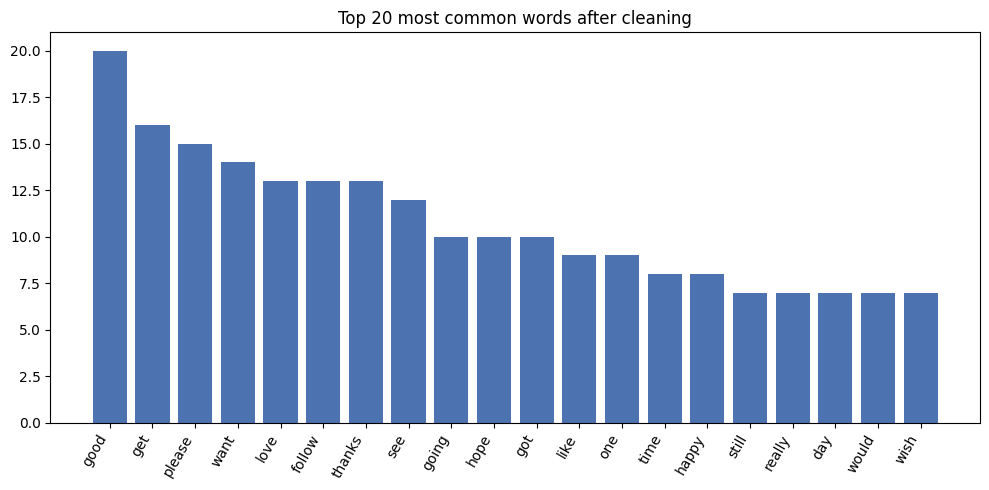

In [20]:
word_counts = Counter(" ".join(df["clean_text"]).split())
top20 = word_counts.most_common(20)
words_, counts_ = zip(*top20)

plt.figure(figsize=(10, 5))
plt.bar(words_, counts_, color="#4C72B0")
plt.xticks(rotation=60, ha="right")
plt.title("Top 20 most common words after cleaning")
plt.tight_layout()
plt.show()

## Wrap-up

The most frequent words left over — "good", "love", "thanks", "happy", "hope" — line up well with this being a sentiment dataset, which is a nice confirmation that the pipeline kept the words that actually carry meaning and dropped the noise around them.

`clean_text` is now in decent shape to be fed into something like a `CountVectorizer`/TF-IDF step or an embedding model for an actual sentiment classifier — that felt outside the scope of this assignment, but it's the natural next step from here.